In [2]:
from telethon import TelegramClient
import pandas as pd
import os
from IPython.display import display, Markdown

from dotenv import load_dotenv
load_dotenv()
from dotenv import find_dotenv
print(find_dotenv())

/Users/agathaallain/Desktop/COLUMBIA/1st project/code/.env


In [3]:
os.environ["TELEGRAM_API_ID"][:3]+"..."

'347...'

In [4]:
os.environ["TELEGRAM_API_HASH"][:8]+"..."

'54439b3a...'

In [5]:
client = TelegramClient(
    'thanks', 
    os.getenv("TELEGRAM_API_ID"), 
    os.getenv("TELEGRAM_API_HASH")
)

In [6]:
messages_data = []

In [7]:
async def scrape_channel_messages(channel_name):
    async with client:
        # Get the channel entity (username for public channels or invite link for private. but you have to be a member of a private channel)
        channel = await client.get_entity(channel_name) # this is just the info for the channel

        # Retrieve all messages with date and time from the channel
        async for message in client.iter_messages(channel): # you can't just pass channel, you need iter (iterate) messages inside channel
            message_date = message.date.strftime('%Y-%m-%d')  # Format as YYYY-MM-DD
            message_time = message.date.strftime('%H:%M:%S')  # Format as HH:MM:SS

            # Generate a link to the message (not important in most cases)
            if message.id:   #messages have id
                message_link = f"https://t.me/{channel.username}/{message.id}"
            else:
                message_link = None
        
            # Get the full text of the message 
            if message.text:
                message_text = message.text
            else:
                message_text = "no text"
                print("No Text")
    
            # Append the data as a dictionary to the messages_data list
            messages_data.append({
                        'Channel Name': channel.title,
                        'Date': message_date,
                        'Time': message_time,
                        'Link': message_link,
                        'Message': message_text
                    })
    
            # Create a DataFrame from the collected data

    df = pd.DataFrame(messages_data)
    return df
    #df goes under async
           

In [8]:
df = await scrape_channel_messages("NemesisParis")
df

No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text
No Text


,Channel Name,Date,Time,Link,Message
0,Collectif Némésis,2026-03-31,19:02:02,https://t.me/NemesisParis/2723,no text
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
...,...,...,...,...,...
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18
2593,Collectif Némésis,2019-10-30,00:11:42,https://t.me/NemesisParis/4,Après seulement quelques heures sur le réseau ...
2594,Collectif Némésis,2019-10-30,00:07:59,https://t.me/NemesisParis/3,no text
2595,Collectif Némésis,2019-10-30,00:00:48,https://t.me/NemesisParis/2,no text


In [9]:
df.to_csv("messages_raw_ALL.csv", index = False)
df

,Channel Name,Date,Time,Link,Message
0,Collectif Némésis,2026-03-31,19:02:02,https://t.me/NemesisParis/2723,no text
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
...,...,...,...,...,...
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18
2593,Collectif Némésis,2019-10-30,00:11:42,https://t.me/NemesisParis/4,Après seulement quelques heures sur le réseau ...
2594,Collectif Némésis,2019-10-30,00:07:59,https://t.me/NemesisParis/3,no text
2595,Collectif Némésis,2019-10-30,00:00:48,https://t.me/NemesisParis/2,no text


In [10]:
df_dropped_duplicates = df.drop_duplicates()
df_dropped_duplicates

,Channel Name,Date,Time,Link,Message
0,Collectif Némésis,2026-03-31,19:02:02,https://t.me/NemesisParis/2723,no text
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
...,...,...,...,...,...
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18
2593,Collectif Némésis,2019-10-30,00:11:42,https://t.me/NemesisParis/4,Après seulement quelques heures sur le réseau ...
2594,Collectif Némésis,2019-10-30,00:07:59,https://t.me/NemesisParis/3,no text
2595,Collectif Némésis,2019-10-30,00:00:48,https://t.me/NemesisParis/2,no text


In [11]:
df_dropped_duplicates = df
df.drop(df[df["Message"].str.contains("no text")].index) 



,Channel Name,Date,Time,Link,Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem..."
...,...,...,...,...,...
2589,Collectif Némésis,2019-10-30,20:19:21,https://t.me/NemesisParis/9,https://instagram.com/parisnemesis?igshid=1bhj...
2590,Collectif Némésis,2019-10-30,19:25:55,https://t.me/NemesisParis/8,https://twitter.com/nemesisnemesi18/status/118...
2591,Collectif Némésis,2019-10-30,14:12:13,https://t.me/NemesisParis/7,https://twitter.com/nemesisnemesi18/status/118...
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18


In [12]:
df_dropped_no_text = df.drop(df[df["Message"].str.contains("no text")].index) 
df_dropped_no_text

,Channel Name,Date,Time,Link,Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem..."
...,...,...,...,...,...
2589,Collectif Némésis,2019-10-30,20:19:21,https://t.me/NemesisParis/9,https://instagram.com/parisnemesis?igshid=1bhj...
2590,Collectif Némésis,2019-10-30,19:25:55,https://t.me/NemesisParis/8,https://twitter.com/nemesisnemesi18/status/118...
2591,Collectif Némésis,2019-10-30,14:12:13,https://t.me/NemesisParis/7,https://twitter.com/nemesisnemesi18/status/118...
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18


In [13]:
df_dropped_no_text.head()

,Channel Name,Date,Time,Link,Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem..."


In [14]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [15]:
import re
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer


In [16]:
#FIRST STEP: we remove accents from all text in the message column, as well as special characters
#this looks like it also removes emojis...

def remove_special_characters(text):
    if not isinstance(text, str):
        return text
    
    # normalize the text (breaks down "é" into "e" + "combining accent")
    normalized = unicodedata.normalize('NFD', text)
    
    # strip out accents
    text = "".join(c for c in normalized if unicodedata.category(c) != 'Mn')

    # replace apostrophes by a blank space
    text = text.replace("'", " ").replace("’", " ")
    
    # apply your existing regex to remove remaining non-alphabetic characters
    return re.sub(r"[^A-Za-z\s]", "", text)

df_dropped_no_text["cleaned_Message"] = df_dropped_no_text["Message"].apply(remove_special_characters)
df_dropped_no_text.head()

,Channel Name,Date,Time,Link,Message,cleaned_Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da...",L homme de type maghrebin l aurait suivie dans...
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...,On continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...,Le CIO retabli les tests genetiques de feminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️,Notre section Bordeaux
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem...",Trois hommes intervenus pour defendre des femm...


In [17]:
#converting to lower cases
df_dropped_no_text["cleaned_Message"] = df_dropped_no_text["cleaned_Message"].apply(lambda x: x.lower())
df_dropped_no_text.head()

,Channel Name,Date,Time,Link,Message,cleaned_Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da...",l homme de type maghrebin l aurait suivie dans...
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...,on continue le tour de nos belles sections ave...
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...,le cio retabli les tests genetiques de feminit...
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️,notre section bordeaux
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem...",trois hommes intervenus pour defendre des femm...


In [18]:
#lemmatization, grouping words according to their lema
#starts with tokenizing first 

nltk.download("punkt")
df_dropped_no_text["tokenized_Message"] = df_dropped_no_text["cleaned_Message"].apply(word_tokenize)

df_dropped_no_text["tokenized_Message"]

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/agathaallain/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


1       [l, homme, de, type, maghrebin, l, aurait, sui...
2       [on, continue, le, tour, de, nos, belles, sect...
3       [le, cio, retabli, les, tests, genetiques, de,...
4                              [notre, section, bordeaux]
5       [trois, hommes, intervenus, pour, defendre, de...
                              ...                        
2589      [httpsinstagramcomparisnemesisigshidbhjlpumpqe]
2590                [httpstwittercomnemesisnemesistatuss]
2591                [httpstwittercomnemesisnemesistatuss]
2592                       [httpstwittercomnemesisnemesi]
2593    [apres, seulement, quelques, heures, sur, le, ...
Name: tokenized_Message, Length: 2024, dtype: object

In [19]:
#lemmatization part 1

nltk.download("wordnet")
nltk.download("omw-1.4")
lemmatizer = WordNetLemmatizer()
df_dropped_no_text["lemmatized_Message"]= df_dropped_no_text["tokenized_Message"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

df_dropped_no_text["lemmatized_Message"]

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/agathaallain/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/agathaallain/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


1       [l, homme, de, type, maghrebin, l, aurait, sui...
2       [on, continue, le, tour, de, no, belle, sectio...
3       [le, cio, retabli, le, test, genetiques, de, f...
4                              [notre, section, bordeaux]
5       [trois, hommes, intervenus, pour, defendre, de...
                              ...                        
2589      [httpsinstagramcomparisnemesisigshidbhjlpumpqe]
2590                [httpstwittercomnemesisnemesistatuss]
2591                [httpstwittercomnemesisnemesistatuss]
2592                       [httpstwittercomnemesisnemesi]
2593    [apres, seulement, quelques, heures, sur, le, ...
Name: lemmatized_Message, Length: 2024, dtype: object

# filter out the stopwords, in french, from nltk library

In [20]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('french'))
nltk.download("stopwords")

df_dropped_no_text["lemmatized_Message"] = df_dropped_no_text["lemmatized_Message"].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/agathaallain/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
df_dropped_no_text

,Channel Name,Date,Time,Link,Message,cleaned_Message,tokenized_Message,lemmatized_Message
1,Collectif Némésis,2026-03-27,19:17:40,https://t.me/NemesisParis/2722,"L’homme, de type maghrébin, l’aurait suivie da...",l homme de type maghrebin l aurait suivie dans...,"[l, homme, de, type, maghrebin, l, aurait, sui...","[homme, type, maghrebin, suivie, rue, avant, c..."
2,Collectif Némésis,2026-03-26,19:57:46,https://t.me/NemesisParis/2721,On continue le tour de nos belles sections ave...,on continue le tour de nos belles sections ave...,"[on, continue, le, tour, de, nos, belles, sect...","[continue, tour, no, belle, section, dijon, be..."
3,Collectif Némésis,2026-03-26,16:32:29,https://t.me/NemesisParis/2720,Le CIO rétabli les tests génétiques de féminit...,le cio retabli les tests genetiques de feminit...,"[le, cio, retabli, les, tests, genetiques, de,...","[cio, retabli, test, genetiques, feminite, par..."
4,Collectif Némésis,2026-03-24,18:21:19,https://t.me/NemesisParis/2719,Notre section Bordeaux 🪽❤️,notre section bordeaux,"[notre, section, bordeaux]","[section, bordeaux]"
5,Collectif Némésis,2026-03-23,16:48:48,https://t.me/NemesisParis/2718,"Trois hommes, intervenus pour défendre des fem...",trois hommes intervenus pour defendre des femm...,"[trois, hommes, intervenus, pour, defendre, de...","[trois, hommes, intervenus, defendre, femmes, ..."
...,...,...,...,...,...,...,...,...
2589,Collectif Némésis,2019-10-30,20:19:21,https://t.me/NemesisParis/9,https://instagram.com/parisnemesis?igshid=1bhj...,httpsinstagramcomparisnemesisigshidbhjlpumpqe,[httpsinstagramcomparisnemesisigshidbhjlpumpqe],[httpsinstagramcomparisnemesisigshidbhjlpumpqe]
2590,Collectif Némésis,2019-10-30,19:25:55,https://t.me/NemesisParis/8,https://twitter.com/nemesisnemesi18/status/118...,httpstwittercomnemesisnemesistatuss,[httpstwittercomnemesisnemesistatuss],[httpstwittercomnemesisnemesistatuss]
2591,Collectif Némésis,2019-10-30,14:12:13,https://t.me/NemesisParis/7,https://twitter.com/nemesisnemesi18/status/118...,httpstwittercomnemesisnemesistatuss,[httpstwittercomnemesisnemesistatuss],[httpstwittercomnemesisnemesistatuss]
2592,Collectif Némésis,2019-10-30,00:16:24,https://t.me/NemesisParis/5,https://twitter.com/NemesisNemesi18,httpstwittercomnemesisnemesi,[httpstwittercomnemesisnemesi],[httpstwittercomnemesisnemesi]


# Save to csv

In [29]:
df_dropped_no_text.to_csv("messages_clean_ALL.csv", index = False)

In [23]:
all_words = " ".join([" ".join(words) for words in df_dropped_no_text["lemmatized_Message"]])


In [24]:
pip install uv

Note: you may need to restart the kernel to use updated packages.


In [25]:
uv init

Initialized project `code`
Note: you may need to restart the kernel to use updated packages.


In [26]:
!uv add matplotlib pyside6


Resolved 16 packages in 36ms                                         
Checked 15 packages in 7ms                                           


In [27]:
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

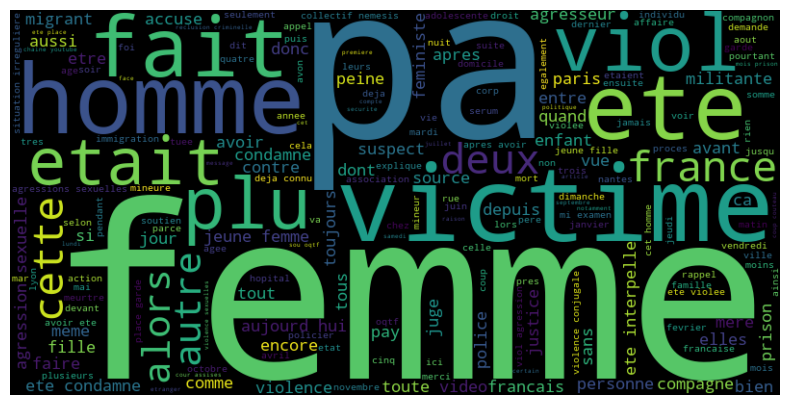

In [28]:
from wordcloud import WordCloud

wordcloud = WordCloud(width = 800, height = 400, background_color="black").generate(all_words)

plt.figure (figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
